In [95]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [96]:
raw_data=pd.read_excel(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\sinthya\Export.xlsx')
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3612 entries, 0 to 3611
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  3612 non-null   str  
 1   Message  3612 non-null   str  
 2   Status   3612 non-null   str  
dtypes: str(3)
memory usage: 84.8 KB


In [97]:
aux=pd.DataFrame()
aux=raw_data
aux['Headers']='NaN'

for i in range(0,aux.shape[0]):
    aux.iloc[i,3]=aux.iloc[i,2][0:8]

aux['Headers'].value_counts()

Headers
0x252513    2858
0x252514     525
0x252501     129
0x252511     100
Name: count, dtype: int64

In [98]:
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3612 entries, 0 to 3611
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  3612 non-null   str  
 1   Message  3612 non-null   str  
 2   Status   3612 non-null   str  
 3   Headers  3612 non-null   str  
dtypes: str(4)
memory usage: 113.0 KB


Odometer

In [99]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
unit_aux['Odometer in meters']=0.0
odometer=[]
date=[]
raw=[]
unit=pd.DataFrame()

for i in range(0,unit_aux.shape[0]):
    odometer.append(int(unit_aux.iloc[i,2][96:104],16))
    date.append(unit_aux.iloc[i,2][106:118])
    raw.append(unit_aux.iloc[i,2])    

unit_aux['Odometer in meters']=odometer
unit_aux['Date']=date
unit_aux['Raw data']=raw

#print(unit_aux['Odometer in meters'])

unit=unit_aux.sort_values('Date',ascending=True)

print(unit.info())

<class 'pandas.DataFrame'>
Index: 3383 entries, 3 to 2
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Created             3383 non-null   str  
 1   Message             3383 non-null   str  
 2   Status              3383 non-null   str  
 3   Headers             3383 non-null   str  
 4   Odometer in meters  3383 non-null   int64
 5   Date                3383 non-null   str  
 6   Raw data            3383 non-null   str  
dtypes: int64(1), str(6)
memory usage: 211.4 KB
None


260822153557 -> 0 -> 0.0 -> 0x252513005900020869487060157640003C38402D00000064CF0000000700646100000000000000FFFFFFFFFFFF00D5000000001026082215355700607F444B0D99C2BBC85D400000000003252569FFFFFF000017FFFFFFFFFF
260822153557 -> 1 -> 0.0 -> 0x252514005900130869487060157640003C38402D00000064CF0000000700646100000000000000FFFFFFFFFFFF16D5000000001026082215355700607F444B0D99C2BBC85D400000000003252525FFFFFF000017FFFFFFFFFF
260822153858 -> 2 -> 301089.0 -> 0x252513005900030869487060157640003C38402D00000052480000000000646100000000000000FFFFFFFFFFFF00D500049821102608221538589A591E450B4794C25BF497400000000003462530FFFFFF00001A0001FFFFFF
260822153959 -> 3 -> 301089.0 -> 0x252513005900040869487060157640003C38402D0000004B470000000000646100000000000001FFFFFFFFFFFF00D500049821102608221539599A591E450B4794C25BF497400000000003502536FFFFFF00001A0001FFFFFF
260822154028 -> 4 -> 301089.0 -> 0x252514005900140869487060157640003C38402D0000004B480000000000646100000000000000FFFFFFFFFFFF03D500049821102608221540289A5

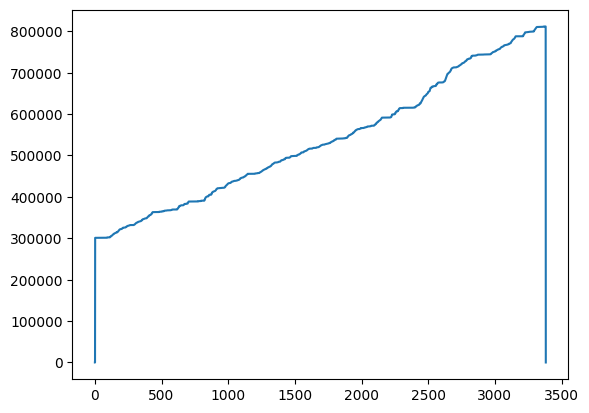

In [100]:
y_axis=[]
x_axis=[]
date=[]
raw_data_=[]

for i in range(0,unit.shape[0]):
    #print(float(fsq694_m_odometer.iloc[i,6][8:15]))
    y_axis.append(float(unit.iloc[i,4]))
    x_axis.append(i)
    date.append(unit.iloc[i,5])
    raw_data_.append(unit.iloc[i,6])

#print("Delta odometer: ",y_axis[170]-y_axis[133],'meters')

for i in range(0,len(odometer)):
    print(date[i],'->',x_axis[i],'->',y_axis[i],'->',raw_data_[i])

#print(odometer[len(odometer)-1]-odometer[0])
plt.plot(x_axis,y_axis)

Speed

In [101]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
#unit_aux['Odometer in meters']=0.0
speed=[]
date=[]
raw=[]
unit_speed=pd.DataFrame()
unit=pd.DataFrame()

for i in range(0,unit_aux.shape[0]):
    try:
        lbs_ind=(bin(int(unit_aux.iloc[i,2][50:52],16) & 64))
        if lbs_ind=='0b1000000':
            speed.append(int(unit_aux.iloc[i,2][142:145]))  
            date.append(unit_aux.iloc[i,2][106:118])
            raw.append(unit_aux.iloc[i,2])
            print(lbs_ind)

    except:
        pass    

unit_speed['Speed']=speed
unit_speed['Date']=date
unit_speed['Raw data']=raw

unit=unit_speed.sort_values('Date',ascending=True)

print(unit.info())

0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000


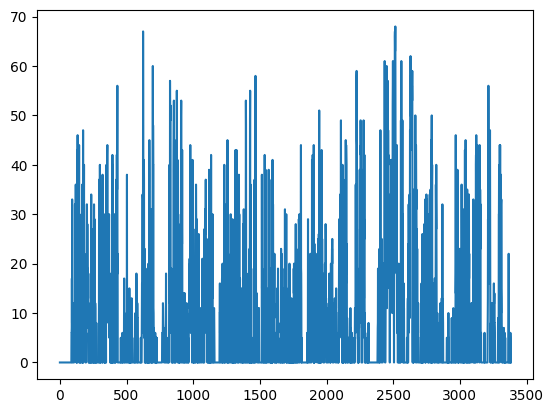

In [102]:
y_axis=[]
x_axis=[]
date=[]
raw_data_=[]

for i in range(0,unit.shape[0]):
    #print(float(fsq694_m_odometer.iloc[i,6][8:15]))
    y_axis.append(float(unit.iloc[i,0]))
    x_axis.append(i)
    date.append(unit.iloc[i,1])
    raw_data_.append(unit.iloc[i,2])

plt.plot(x_axis,y_axis)

Historical events

In [103]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
satellite_number=[]
satellite_connection_indicator=[]
date=[]
raw=[]
num_events=0

for i in range(0,unit_aux.shape[0]):
    satellite_number.append(int(unit_aux.iloc[i,2][50:52],16) & 31)
    satellite_connection_indicator.append(int(unit_aux.iloc[i,2][50:52],16) & 0b10000000)
    date.append(unit_aux.iloc[i,2][106:118])
    raw.append(unit_aux.iloc[i,2])    

print(satellite_connection_indicator)
unit_aux['Satellites']=satellite_number
unit_aux['Satellite_connection_indicator']=satellite_connection_indicator
unit_aux['Raw data']=raw
unit_aux['date']=date

unit=unit_aux.sort_values('date',ascending=True)

unit.info()

for i in range(0,unit.shape[0]):
    if unit.iloc[i,5]>0:
        num_events=num_events+1
        print(unit.iloc[i,5],'->', unit.iloc[i,0], '->',unit.iloc[i,4],'->',unit.iloc[i,6])

print("Eventos históricos: ",num_events)

[128, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 128, 0, 0, 0, 128, 0, 0, 0, 128, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 128, 0, 0, 128, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 128, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 128, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 128, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 128, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 128, 0, 128, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 128, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 128, 0, 0, 0, 0, 0, 0, 0, 128, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 128, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0

Satellites Number

In [104]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
satellite_number=[]
satellite_connection_indicator=[]
date=[]
raw=[]
num_events=0

for i in range(0,unit_aux.shape[0]):
    satellite_number.append(int(unit_aux.iloc[i,2][50:52],16) & 31)
    satellite_connection_indicator.append(int(unit_aux.iloc[i,2][50:52],16) & 128)
    date.append(unit_aux.iloc[i,2][106:118])
    raw.append(unit_aux.iloc[i,2])    

unit_aux['Satellites']=satellite_number
unit_aux['Satellite_connection_indicator']=satellite_connection_indicator
unit_aux['Raw data']=raw
unit_aux['date']=date

unit=unit_aux.sort_values('date',ascending=True)

unit.info()

for i in range(0,unit.shape[0]):
    if unit.iloc[i,4]<2:
        num_events=num_events+1
        print(unit.iloc[i,5],'->', unit.iloc[i,0], '->',unit.iloc[i,4],'->',unit.iloc[i,6])

print("Eventos históricos: ",num_events)

<class 'pandas.DataFrame'>
Index: 3383 entries, 3 to 2
Data columns (total 8 columns):
 #   Column                          Non-Null Count  Dtype
---  ------                          --------------  -----
 0   Created                         3383 non-null   str  
 1   Message                         3383 non-null   str  
 2   Status                          3383 non-null   str  
 3   Headers                         3383 non-null   str  
 4   Satellites                      3383 non-null   int64
 5   Satellite_connection_indicator  3383 non-null   int64
 6   Raw data                        3383 non-null   str  
 7   date                            3383 non-null   str  
dtypes: int64(2), str(6)
memory usage: 237.9 KB
Eventos históricos:  0


Coordinates

In [105]:
import struct

unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
latitude=[]
lat_aux=[]
longitude=[]
lon_aux=[]
speed=[]
date=[]
raw=[]
num_events=0

for i in range(0,unit_aux.shape[0]):
    latitude.append(unit_aux.iloc[i,2][134:142])
    longitude.append(unit_aux.iloc[i,2][126:134])
    lon_aux.append(struct.unpack('<f', bytes.fromhex(unit_aux.iloc[i,2][126:134]))[0])
    lat_aux.append(struct.unpack('<f', bytes.fromhex(unit_aux.iloc[i,2][134:142]))[0])    
    speed.append(int(unit_aux.iloc[i,2][142:145],16))
    date.append(unit_aux.iloc[i,2][106:118])
    raw.append(unit_aux.iloc[i,2])    

unit_aux['Latitude']=latitude
unit_aux['Latitude_decoded']=lat_aux
unit_aux['Longitude']=longitude
unit_aux['Longitude_decoded']=lon_aux
unit_aux['Raw data']=raw
unit_aux['Date']=date
unit_aux['Speed']=speed

unit=unit_aux.sort_values('Date',ascending=True)

print(unit.info())

for i in range(0,unit.shape[0]):
    num_events=num_events+1
    print(unit.iloc[i,9],'->', unit.iloc[i,4], '->',unit.iloc[i,5],'->',unit.iloc[i,6],'->',unit.iloc[i,7],unit.iloc[i,8])

<class 'pandas.DataFrame'>
Index: 3383 entries, 3 to 2
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Created            3383 non-null   str    
 1   Message            3383 non-null   str    
 2   Status             3383 non-null   str    
 3   Headers            3383 non-null   str    
 4   Latitude           3383 non-null   str    
 5   Latitude_decoded   3383 non-null   float64
 6   Longitude          3383 non-null   str    
 7   Longitude_decoded  3383 non-null   float64
 8   Raw data           3383 non-null   str    
 9   Date               3383 non-null   str    
 10  Speed              3383 non-null   int64  
dtypes: float64(2), int64(1), str(8)
memory usage: 317.2 KB
None
260822153557 -> BBC85D40 -> 3.465376615524292 -> 4B0D99C2 -> -76.52596282958984 0x252513005900020869487060157640003C38402D00000064CF0000000700646100000000000000FFFFFFFFFFFF00D5000000001026082215355700607F444B0D99C2BBC85D400

In/Outs

15      14                 13      12      11      10      09      08       07 06 05 04 03 02 01 00
Power   Ignition/Input0    Input1  Input2  Input3  Input4  Input5  Input0

15=0, Connected
15=1. Disconnected

In [106]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
unit_aux.info()
aux_cad=[]
aux_date=[]
aux_raw_data=[]
aux_input_number=[]
in_outs=[]

#unit_aux.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\sym\concatenated.csv')

for i in range(0,unit_aux.shape[0]):
    long_cad=len(unit_aux.iloc[i,2])
    if ((long_cad>48) & (long_cad<204)):
        aux_cad.append(unit_aux.iloc[i,2])   

for i in range(0,len(aux_cad)):
    aux_value=aux_cad[i][64:68]
    aux_date.append(aux_cad[i][106:118])
    aux_raw_data.append(aux_cad[i])
    in_outs.append(bin (int (aux_cad[i][64:68],16) ))      

unit_=pd.DataFrame()
unit_['in and outs']=in_outs
unit_['date']=aux_date
unit_['raw data']=aux_raw_data

in_outs_df=unit_.sort_values('date',ascending=True)

in_outs_df.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\sinthya\in_outs.csv')

<class 'pandas.DataFrame'>
Index: 3383 entries, 3 to 3607
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  3383 non-null   str  
 1   Message  3383 non-null   str  
 2   Status   3383 non-null   str  
 3   Headers  3383 non-null   str  
dtypes: str(4)
memory usage: 132.1 KB


Detección de puertas

In [107]:
x='0b0011000000000000' # for 16 bits, len=18

print(len(x),(x[4:6]))

y='0b011000000000000'   # for 15 bits, len=17
print(len(y), (y[3:5]))


18 11
17 11


In [108]:
in_outs=pd.read_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\sinthya\in_outs.csv',sep=',')
in_outs.info()
for i in range(0,in_outs.shape[0]):
    aux=(in_outs.iloc[i,1])
    if len(aux)==18:
        aux_2=(in_outs.iloc[i,1][4:6])
        if aux_2=='11':
            print(in_outs.iloc[i,1],len(aux),aux_2)
    if len(aux)==17:
        aux_2=(in_outs.iloc[i,1][3:5])
        if aux_2=='11':
            print(in_outs.iloc[i,1],len(aux),aux_2)

<class 'pandas.DataFrame'>
RangeIndex: 3378 entries, 0 to 3377
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Unnamed: 0   3378 non-null   int64
 1   in and outs  3378 non-null   str  
 2   date         3378 non-null   int64
 3   raw data     3378 non-null   str  
dtypes: int64(2), str(2)
memory usage: 105.7 KB


Detección de pánico

In [109]:
unit_.info()

<class 'pandas.DataFrame'>
RangeIndex: 3378 entries, 0 to 3377
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   in and outs  3378 non-null   str  
 1   date         3378 non-null   str  
 2   raw data     3378 non-null   str  
dtypes: str(3)
memory usage: 79.3 KB


In [110]:
for i in range(0,unit_.shape[0]):
    if unit_.iloc[i,2][92:94]=='42':
        print(unit_.iloc[i,2],unit_.iloc[i,1])

0x252514005900120869487060157640003C38402D000000644F0000000700646000000000020001FFFFFFFFFFFF42D5000000001027032505403200607F444B0D99C2BBC85D400000000003212578FFFFFF000016FFFFFFFFFF 270325054032
0x2525140059001D0869487060157640003C38402D0000004B500000000700642000000000000000FFFFFFFFFFFF42D500049821102608221544199A591E450B4794C25BF497400000000003582545FFFFFF00001B0000FFFFFF 260822154419
0x252514005900200869487060157640003C38402D000000524F0000000700646100000000000000FFFFFFFFFFFF42D500049821102608221546119A591E450B4794C25BF497400000000003602534FFFFFF00001B0000FFFFFF 260822154611
0x252514005900220869487060157640003C38402D0000004F510000000700646100000000040000FFFFFFFFFFFF42D500049821102608221547429A591E450B4794C25BF497400000000003602536FFFFFF00001B0000FFFFFF 260822154742
0x252514005900240869487060157640003C38402D0000004F500000000700646100000000000000FFFFFFFFFFFF42D500049821102608221547449A591E450B4794C25BF497400000000003602534FFFFFF00001B0000FFFFFF 260822154744
0x2525140059002708694870601576